# 02 — Regime Detection

This notebook estimates latent market regimes from the feature panel created in `01_data_pipeline`.

The objective is not to discover a perfect market-state classifier. The objective is to construct an interpretable state variable that can be used for:

1. regime-conditioned risk diagnostics,
2. allocation stress control,
3. SMDP-inspired intervention policies.

The notebook follows the project design principle:

> notebooks are visual research interfaces; reusable logic lives in `src/regime_portfolio`.

## Research objective

Estimate ordered market regimes and verify that the resulting states are economically interpretable.

The notebook should answer:

- Do the latent regimes correspond to different stress-score levels?
- Are regime labels persistent enough to be meaningful?
- Are the model probabilities confident or ambiguous?
- Does the high-stress regime represent rare stress episodes rather than noise?
- Are the exported regime labels suitable for downstream risk and allocation notebooks?

## Expected local outputs

Core pipeline outputs:

- `data/processed/regime_labels.csv`
- `data/processed/regime_probabilities.csv`
- `data/processed/hmm_transition_matrix.csv`
- `data/processed/regime_durations.csv`

Diagnostic outputs:

- `data/processed/regime_interpretation.csv`
- `data/processed/regime_confidence_diagnostics.csv`
- `data/processed/regime_switch_audit.csv`
- `data/processed/empirical_regime_transition_matrix.csv`
- `data/processed/regime_detection_manifest.csv`

Figures:

- `reports/figures/02_stress_score_and_regimes.png`
- `reports/figures/02_regime_probabilities.png`
- `reports/figures/02_hmm_transition_matrix.png`

Interpretation rule:

> A regime model is useful only if the states are interpretable, persistent, and materially related to risk conditions. It should not be presented as a crisis-prediction engine.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
from regime_portfolio.features import stress_score
from regime_portfolio.regimes import (
    RegimeDetector,
    apply_minimum_regime_duration,
    regime_durations,
    smooth_regime_probabilities,
)
from regime_portfolio.smdp_policy import estimate_transition_matrix

## 1. Load processed inputs

This notebook starts from the cleaned files exported by `01_data_pipeline`.

This is important for reproducibility: regime detection should not silently re-download or reshape data.

In [3]:
prices = pd.read_csv(DATA_DIR / "prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
risk_features = pd.read_csv(DATA_DIR / "risk_features.csv", index_col=0, parse_dates=True)

print("Prices:", prices.shape)
print("Returns:", returns.shape)
print("Features:", risk_features.shape)

display(risk_features.tail())

Prices: (4852, 7)
Returns: (4851, 7)
Features: (4789, 5)


,SPY_realized_vol,SPY_drawdown,avg_corr,SPY_momentum,SPY_downside_semivol
Date,,,,,
2026-06-05,0.1294,-0.0290,0.1136,0.0999,0.0872
2026-06-08,0.1290,-0.0268,0.1140,0.0928,0.0872
2026-06-09,0.1263,-0.0296,0.1145,0.0914,0.0872
2026-06-10,0.1373,-0.0449,0.1172,0.0755,0.0909
2026-06-11,0.1504,-0.0287,0.1251,0.1107,0.0876


## 2. Construct a transparent stress score

Before fitting the HMM, we compute a deterministic stress score from the feature panel.

This score is not the final regime model. It is used for interpretation and for ordering the hidden states economically.

Higher stress should typically correspond to:

- higher volatility,
- deeper drawdowns,
- higher downside semivolatility,
- higher average correlation,
- weaker momentum.

In [4]:
score = stress_score(risk_features)

stress_score_summary = score.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame(name="stress_score")

print("Stress-score summary")
display(stress_score_summary)

print("Stress-score tail")
display(score.tail().to_frame())

Stress-score summary


,stress_score
count,"4,789.0000"
mean,0.0000
std,0.4049
min,-1.2029
1%,-0.6968
5%,-0.4917
25%,-0.2331
50%,-0.0759
75%,0.1497
95%,0.7550


Stress-score tail


,stress_score
Date,
2026-06-05,-0.0025
2026-06-08,0.0214
2026-06-09,0.0155
2026-06-10,0.0621
2026-06-11,0.0537


## 3. Fit a Gaussian HMM

Raw HMM labels are arbitrary: state `0` does not naturally mean "calm" or "crisis".

The project therefore uses the `RegimeDetector` class from `src/regime_portfolio/regimes.py`, which:

1. standardizes the feature panel,
2. fits a Gaussian HMM,
3. predicts raw states,
4. reorders states by an economic stress proxy.

The ordered labels follow the convention:

```text
0 = lowest stress
1 = intermediate stress
2 = highest stress

In [5]:
N_REGIMES = 3
MIN_REGIME_DURATION = 5
PROBABILITY_SMOOTHING_WINDOW = 5

detector = RegimeDetector(
    n_regimes=N_REGIMES,
    covariance_type="full",
    n_iter=1_000,
    random_state=42,
)

detector.fit(risk_features, risk_proxy=score)

regimes_raw_ordered = detector.predict(risk_features).rename("regime_raw_ordered")
regime_probabilities = detector.predict_proba(risk_features)
regime_probabilities_smoothed = smooth_regime_probabilities(
    regime_probabilities,
    window=PROBABILITY_SMOOTHING_WINDOW,
)

hmm_transition_matrix = detector.transition_matrix()

hmm_config = pd.Series(
    {
        "n_regimes": N_REGIMES,
        "covariance_type": detector.covariance_type,
        "n_iter": detector.n_iter,
        "random_state": detector.random_state,
        "minimum_regime_duration_filter": MIN_REGIME_DURATION,
        "probability_smoothing_window": PROBABILITY_SMOOTHING_WINDOW,
        "n_observations_used": len(regimes_raw_ordered),
        "feature_start": risk_features.index.min().date(),
        "feature_end": risk_features.index.max().date(),
    },
    name="value",
)

print("HMM configuration")
display(hmm_config.to_frame())

print("Ordered HMM transition matrix")
display(hmm_transition_matrix)

HMM configuration


,value
n_regimes,3
covariance_type,full
n_iter,1000
random_state,42
minimum_regime_duration_filter,5
probability_smoothing_window,5
n_observations_used,4789
feature_start,2007-05-31
feature_end,2026-06-11


Ordered HMM transition matrix


,regime_0,regime_1,regime_2
regime_0,0.9897,0.0103,0.0000
regime_1,0.0174,0.9800,0.0026
regime_2,0.0000,0.0077,0.9923


## 3.1 Regime interpretation before duration filtering

Raw HMM labels are not economically meaningful by themselves.

The `RegimeDetector` orders them by stress score, but we still need to verify the interpretation. The table below summarizes each ordered regime using:

- observation count,
- average stress score,
- median stress score,
- average realized volatility,
- average drawdown,
- average cross-asset correlation,
- average momentum,
- average downside semivolatility.

A credible ordered regime model should show deterioration in several of these dimensions as the regime index increases.

In [6]:
regime_interpretation_raw = pd.concat(
    [
        regimes_raw_ordered.rename("regime"),
        score.rename("stress_score"),
        risk_features,
    ],
    axis=1,
).dropna()

regime_interpretation = (
    regime_interpretation_raw
    .groupby("regime")
    .agg(
        n_obs=("stress_score", "size"),
        stress_score_mean=("stress_score", "mean"),
        stress_score_median=("stress_score", "median"),
        spy_realized_vol_mean=("SPY_realized_vol", "mean"),
        spy_drawdown_mean=("SPY_drawdown", "mean"),
        avg_corr_mean=("avg_corr", "mean"),
        spy_momentum_mean=("SPY_momentum", "mean"),
        spy_downside_semivol_mean=("SPY_downside_semivol", "mean"),
    )
)

regime_interpretation["share_of_sample"] = (
    regime_interpretation["n_obs"] / regime_interpretation["n_obs"].sum()
)

regime_labels = {
    0: "low_stress",
    1: "intermediate_stress",
    2: "high_stress",
}

regime_interpretation["interpretation"] = regime_interpretation.index.map(regime_labels)

display(regime_interpretation)

,n_obs,stress_score_mean,stress_score_median,spy_realized_vol_mean,spy_drawdown_mean,avg_corr_mean,spy_momentum_mean,spy_downside_semivol_mean,share_of_sample,interpretation
regime,,,,,,,,,,
0,2725,-0.1447,-0.1466,0.1060,-0.0099,0.0651,0.0597,0.0677,0.5690,low_stress
1,1546,0.1167,0.0964,0.1975,-0.0837,0.0501,-0.0091,0.1185,0.3228,intermediate_stress
2,518,0.4133,0.3328,0.3630,-0.2150,0.0248,-0.0199,0.2438,0.1082,high_stress


## 4. Apply a minimum-duration filter

Very short regime flips are difficult to interpret economically and can create unstable allocation decisions.

We therefore apply a simple minimum-duration filter. This is not meant to hide genuine transitions; it is a readability and robustness device for the first public version.

In [7]:
regimes = apply_minimum_regime_duration(
    regimes_raw_ordered,
    min_duration=MIN_REGIME_DURATION,
).rename("regime")

durations = regime_durations(regimes)

raw_switch_count = int(regimes_raw_ordered.ne(regimes_raw_ordered.shift()).sum() - 1)
filtered_switch_count = int(regimes.ne(regimes.shift()).sum() - 1)

regime_count_comparison = pd.concat(
    [
        regimes_raw_ordered.value_counts().sort_index().rename("raw_ordered_count"),
        regimes.value_counts().sort_index().rename("filtered_count"),
    ],
    axis=1,
)

regime_count_comparison["raw_ordered_share"] = (
    regime_count_comparison["raw_ordered_count"]
    / regime_count_comparison["raw_ordered_count"].sum()
)

regime_count_comparison["filtered_share"] = (
    regime_count_comparison["filtered_count"]
    / regime_count_comparison["filtered_count"].sum()
)

regime_switch_audit = pd.Series(
    {
        "raw_switch_count": raw_switch_count,
        "filtered_switch_count": filtered_switch_count,
        "switches_removed_by_filter": raw_switch_count - filtered_switch_count,
        "minimum_duration_filter": MIN_REGIME_DURATION,
        "n_filtered_spells": len(durations),
    },
    name="value",
)

duration_summary = (
    durations
    .groupby("regime")["duration"]
    .describe()
)

print("Regime count comparison")
display(regime_count_comparison)

print("Regime switch audit")
display(regime_switch_audit.to_frame())

print("Filtered-regime duration summary")
display(duration_summary)

Regime count comparison


,raw_ordered_count,filtered_count,raw_ordered_share,filtered_share
0,2725,2728,0.5690,0.5696
1,1546,1542,0.3228,0.3220
2,518,519,0.1082,0.1084


Regime switch audit


,value
raw_switch_count,60
filtered_switch_count,57
switches_removed_by_filter,3
minimum_duration_filter,5
n_filtered_spells,58


Filtered-regime duration summary


,count,mean,std,min,25%,50%,75%,max
regime,,,,,,,,
0,26.0000,104.9231,95.9287,13.0000,40.2500,68.0000,138.5000,385.0000
1,28.0000,55.0714,77.0593,5.0000,10.7500,27.0000,56.7500,320.0000
2,4.0000,129.7500,87.7777,65.0000,71.0000,99.5000,158.2500,255.0000


## 4.1 Transition-matrix audit

The HMM transition matrix is model-implied: it comes from the fitted latent-state model.

The empirical transition matrix is computed directly from the final filtered regime labels used downstream.

If the two matrices are nearly identical, the empirical matrix does not add a new visual message. Instead, it becomes an audit check:

> the filtered regime labels preserve the transition behavior learned by the HMM.

This is useful because the downstream notebooks consume the filtered labels, not the internal HMM transition matrix.

In [14]:
empirical_transition_matrix = estimate_transition_matrix(
    regimes,
    n_states=N_REGIMES,
)

# Harmonize labels before comparing matrices.
ordered_labels = [f"regime_{i}" for i in range(N_REGIMES)]

empirical_transition_matrix.index = ordered_labels
empirical_transition_matrix.columns = ordered_labels

hmm_transition_matrix = hmm_transition_matrix.copy()
hmm_transition_matrix.index = ordered_labels
hmm_transition_matrix.columns = ordered_labels

transition_difference = (
    empirical_transition_matrix - hmm_transition_matrix
).rename_axis(index="from_regime", columns="to_regime")

absolute_transition_difference = transition_difference.abs()

transition_audit = pd.Series(
    {
        "max_absolute_difference": absolute_transition_difference.to_numpy().max(),
        "mean_absolute_difference": absolute_transition_difference.to_numpy().mean(),
        "matrices_equal_after_rounding_2_decimals": bool(
            empirical_transition_matrix.round(2).equals(hmm_transition_matrix.round(2))
        ),
        "matrices_equal_after_rounding_4_decimals": bool(
            empirical_transition_matrix.round(4).equals(hmm_transition_matrix.round(4))
        ),
    },
    name="value",
)

print("Model-implied HMM transition matrix")
display(hmm_transition_matrix)

print("Empirical transition matrix from final filtered labels")
display(empirical_transition_matrix)

print("Difference: empirical minus HMM")
display(transition_difference)

print("Transition-matrix audit")
display(transition_audit.to_frame())

Model-implied HMM transition matrix


,regime_0,regime_1,regime_2
regime_0,0.9897,0.0103,0.0000
regime_1,0.0174,0.9800,0.0026
regime_2,0.0000,0.0077,0.9923


Empirical transition matrix from final filtered labels


,regime_0,regime_1,regime_2
regime_0,0.9908,0.0092,0.0000
regime_1,0.0156,0.9818,0.0026
regime_2,0.0019,0.0058,0.9923


Difference: empirical minus HMM


to_regime,regime_0,regime_1,regime_2
from_regime,,,
regime_0,0.0011,-0.0011,-0.0000
regime_1,-0.0019,0.0018,0.0000
regime_2,0.0019,-0.0019,-0.0000


Transition-matrix audit


,value
max_absolute_difference,0.0019
mean_absolute_difference,0.0011
matrices_equal_after_rounding_2_decimals,True
matrices_equal_after_rounding_4_decimals,False


## 4.2 Regime-probability confidence diagnostics

The smoothed probability plot can be visually misleading when the HMM assigns near-binary probabilities.

We therefore compute simple confidence diagnostics:

- maximum assigned regime probability,
- entropy of the regime-probability vector,
- share of dates with high confidence,
- share of dates with ambiguous assignments.

These diagnostics help determine whether the HMM behaves like a soft probabilistic model or closer to a hard segmentation algorithm.

In [9]:
probability_frame = regime_probabilities.copy()

max_probability = probability_frame.max(axis=1).rename("max_probability")

probability_entropy = (
    -probability_frame
    .clip(lower=1e-12)
    .mul(np.log(probability_frame.clip(lower=1e-12)))
    .sum(axis=1)
    .rename("probability_entropy")
)

confidence_diagnostics = pd.Series(
    {
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": max_probability.median(),
        "share_max_probability_above_90pct": (max_probability >= 0.90).mean(),
        "share_max_probability_above_99pct": (max_probability >= 0.99).mean(),
        "share_max_probability_below_70pct": (max_probability < 0.70).mean(),
        "mean_probability_entropy": probability_entropy.mean(),
        "median_probability_entropy": probability_entropy.median(),
    },
    name="value",
)

probability_diagnostics_by_regime = pd.concat(
    [
        regimes.rename("regime"),
        max_probability,
        probability_entropy,
    ],
    axis=1,
).dropna()

probability_diagnostics_by_regime = (
    probability_diagnostics_by_regime
    .groupby("regime")
    .agg(
        n_obs=("max_probability", "size"),
        mean_max_probability=("max_probability", "mean"),
        median_max_probability=("max_probability", "median"),
        mean_entropy=("probability_entropy", "mean"),
        median_entropy=("probability_entropy", "median"),
    )
)

print("Overall probability-confidence diagnostics")
display(confidence_diagnostics.to_frame())

print("Probability-confidence diagnostics by final regime")
display(probability_diagnostics_by_regime)

Overall probability-confidence diagnostics


,value
mean_max_probability,0.9895
median_max_probability,1.0000
share_max_probability_above_90pct,0.9645
share_max_probability_above_99pct,0.9298
share_max_probability_below_70pct,0.0132
mean_probability_entropy,0.0251
median_probability_entropy,0.0000


Probability-confidence diagnostics by final regime


,n_obs,mean_max_probability,median_max_probability,mean_entropy,median_entropy
regime,,,,,
0,2728,0.9888,1.0000,0.0261,0.0000
1,1542,0.9884,1.0000,0.0291,0.0000
2,519,0.9962,1.0000,0.0083,0.0000


## 5. Visual diagnostic — stress score and regimes

This figure overlays the deterministic stress score with the ordered HMM regime label.

The main question is interpretability:

> Do higher-regime periods correspond to visibly more fragile market conditions?

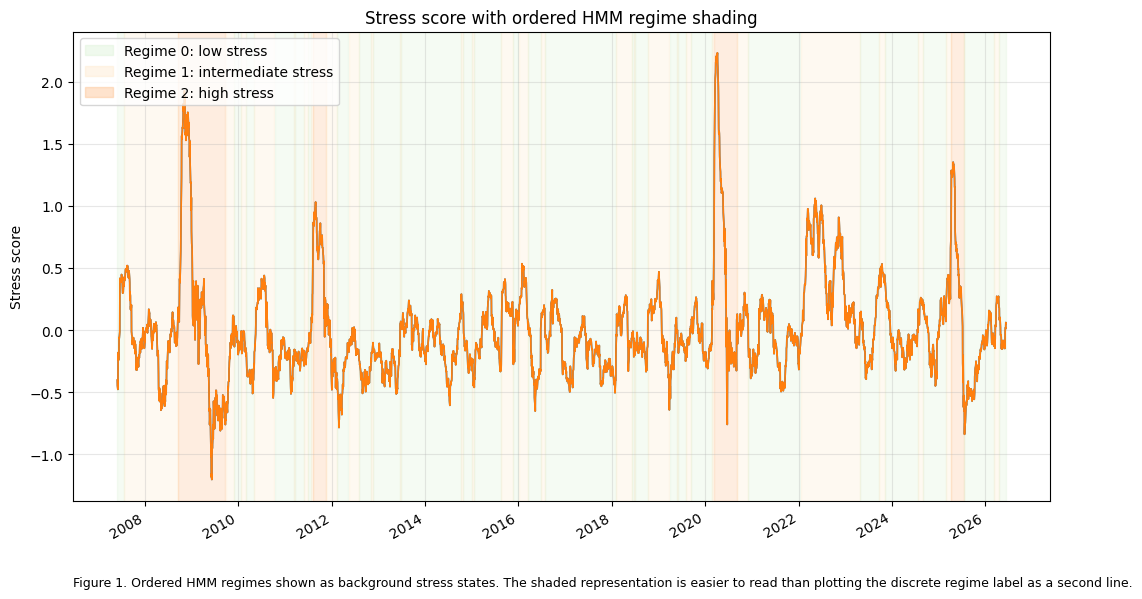

In [10]:
plot_df = pd.concat(
    [
        score.rename("stress_score"),
        regimes.rename("regime"),
    ],
    axis=1,
).dropna()

fig, ax = plt.subplots(figsize=(12, 6))

plot_df["stress_score"].plot(ax=ax, linewidth=1.2)

regime_colors = {
    0: "#d9f0d3",
    1: "#fee8c8",
    2: "#fdbb84",
}

switch_groups = plot_df["regime"].ne(plot_df["regime"].shift()).cumsum()

for _, block in plot_df.groupby(switch_groups):
    regime = int(block["regime"].iloc[0])
    ax.axvspan(
        block.index[0],
        block.index[-1],
        color=regime_colors.get(regime, "lightgrey"),
        alpha=0.25,
    )

plot_df["stress_score"].plot(ax=ax, linewidth=1.2)

ax.set_title("Stress score with ordered HMM regime shading")
ax.set_ylabel("Stress score")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=regime_colors[0], alpha=0.4, label="Regime 0: low stress"),
    plt.Rectangle((0, 0), 1, 1, color=regime_colors[1], alpha=0.4, label="Regime 1: intermediate stress"),
    plt.Rectangle((0, 0), 1, 1, color=regime_colors[2], alpha=0.4, label="Regime 2: high stress"),
]

ax.legend(handles=legend_handles, loc="upper left")

caption = (
    "Figure 1. Ordered HMM regimes shown as background stress states. "
    "The shaded representation is easier to read than plotting the discrete regime label as a second line."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_stress_score_and_regimes.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure interpretation.**  
The ordered regime series should be read as a stress-state segmentation, not as a crisis-prediction model.

The shaded areas make the regime chronology auditable:

- regime 0 should correspond to lower stress-score environments,
- regime 1 should capture intermediate fragility,
- regime 2 should capture rare high-stress episodes.

The main validation question is whether this segmentation leads to materially different risk estimates in the next notebook.

## 6. Visual diagnostic — smoothed regime probabilities

Regime probabilities are useful because they show uncertainty.

A hard label can make the model look more confident than it really is. The probability plot helps identify ambiguous transition periods.

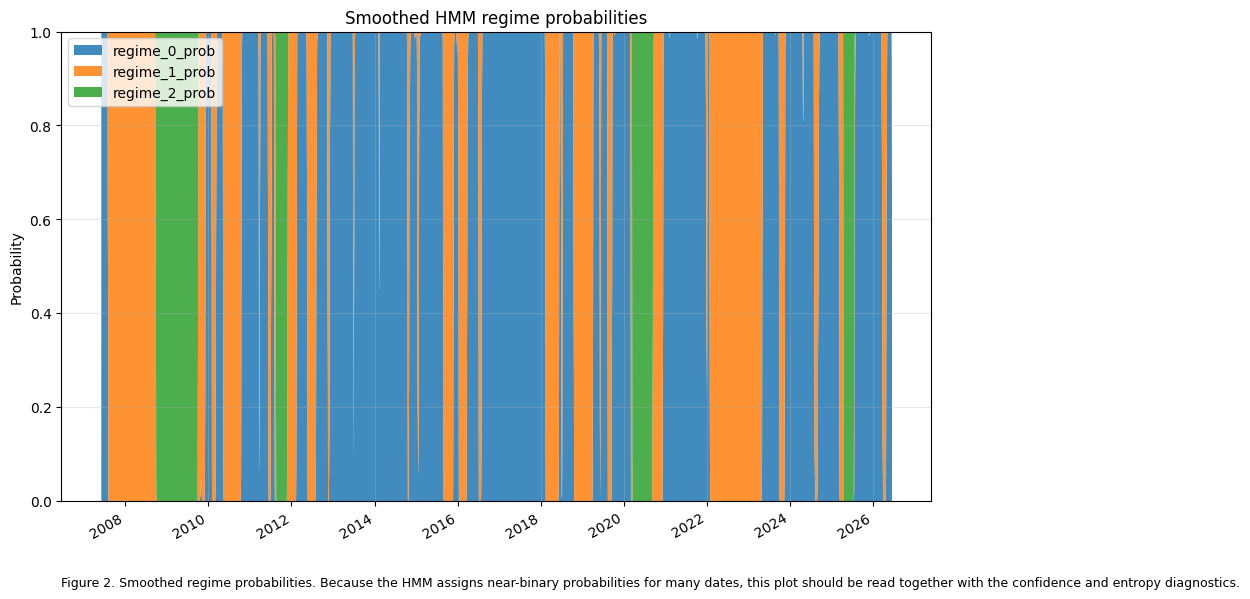

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

regime_probabilities_smoothed.plot.area(
    ax=ax,
    stacked=True,
    linewidth=0.0,
    alpha=0.85,
)

ax.set_title("Smoothed HMM regime probabilities")
ax.set_ylabel("Probability")
ax.set_xlabel("")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

caption = (
    "Figure 2. Smoothed regime probabilities. "
    "Because the HMM assigns near-binary probabilities for many dates, this plot should be read together "
    "with the confidence and entropy diagnostics."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_regime_probabilities.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Visual diagnostic — transition matrix

The transition matrix summarizes estimated regime persistence.

High diagonal probabilities indicate persistent regimes. Large probabilities from low stress directly to high stress, or from high stress directly to low stress, would require interpretation and robustness checks.

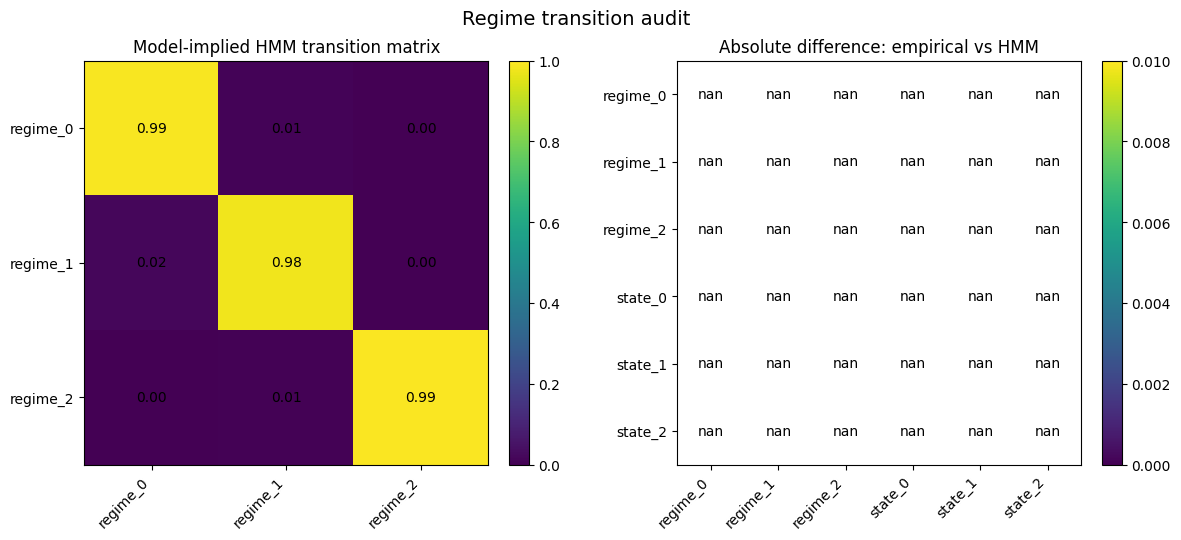

In [12]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
    constrained_layout=True,
)

# Panel 1: HMM transition matrix
matrix = hmm_transition_matrix

im0 = axes[0].imshow(matrix.values, vmin=0.0, vmax=1.0)
axes[0].set_title("Model-implied HMM transition matrix")
axes[0].set_xticks(range(matrix.shape[1]))
axes[0].set_yticks(range(matrix.shape[0]))
axes[0].set_xticklabels(matrix.columns, rotation=45, ha="right")
axes[0].set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        axes[0].text(
            j,
            i,
            f"{matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

# Panel 2: absolute difference between empirical and HMM matrices
diff_matrix = absolute_transition_difference

im1 = axes[1].imshow(diff_matrix.values, vmin=0.0, vmax=max(0.01, diff_matrix.to_numpy().max()))
axes[1].set_title("Absolute difference: empirical vs HMM")
axes[1].set_xticks(range(diff_matrix.shape[1]))
axes[1].set_yticks(range(diff_matrix.shape[0]))
axes[1].set_xticklabels(diff_matrix.columns, rotation=45, ha="right")
axes[1].set_yticklabels(diff_matrix.index)

for i in range(diff_matrix.shape[0]):
    for j in range(diff_matrix.shape[1]):
        axes[1].text(
            j,
            i,
            f"{diff_matrix.iloc[i, j]:.4f}",
            ha="center",
            va="center",
        )

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Regime transition audit", y=1.05, fontsize=14)

fig.savefig(FIGURE_DIR / "02_hmm_transition_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure interpretation.**  
The transition audit shows two related objects:

1. the model-implied HMM transition matrix;
2. the absolute difference between that matrix and the empirical transition matrix computed from the final filtered labels.

In this run, the empirical transition probabilities are nearly identical to the HMM transition probabilities after rounding. This means the minimum-duration filtering step did not materially distort the transition behavior of the fitted HMM.

Therefore, the empirical matrix is not useful as a second visual object, but it is useful as a validation check.

The high diagonal values indicate very persistent regimes. This supports using the labels as slow-moving stress states for risk conditioning and allocation control. It also means the model should not be interpreted as a high-frequency market-timing signal.

## 8. Export regime outputs

These files are the interface to downstream notebooks:

```text
02_regime_detection
  -> regime_labels.csv
  -> regime_probabilities.csv
  -> hmm_transition_matrix.csv
  -> regime_durations.csv

In [13]:
regimes.to_frame().to_csv(DATA_DIR / "regime_labels.csv")
regime_probabilities_smoothed.to_csv(DATA_DIR / "regime_probabilities.csv")
hmm_transition_matrix.to_csv(DATA_DIR / "hmm_transition_matrix.csv")
durations.to_csv(DATA_DIR / "regime_durations.csv", index=False)

regime_interpretation.to_csv(DATA_DIR / "regime_interpretation.csv")
confidence_diagnostics.to_frame().to_csv(DATA_DIR / "regime_confidence_diagnostics.csv")
regime_switch_audit.to_frame().to_csv(DATA_DIR / "regime_switch_audit.csv")
empirical_transition_matrix.to_csv(DATA_DIR / "empirical_regime_transition_matrix.csv")

regime_detection_manifest = pd.DataFrame(
    [
        {
            "artifact": "regime_labels.csv",
            "path": str(DATA_DIR / "regime_labels.csv"),
            "rows": regimes.shape[0],
            "columns": 1,
            "start_date": regimes.index.min().date(),
            "end_date": regimes.index.max().date(),
            "purpose": "Final filtered ordered regime labels used by downstream notebooks.",
        },
        {
            "artifact": "regime_probabilities.csv",
            "path": str(DATA_DIR / "regime_probabilities.csv"),
            "rows": regime_probabilities_smoothed.shape[0],
            "columns": regime_probabilities_smoothed.shape[1],
            "start_date": regime_probabilities_smoothed.index.min().date(),
            "end_date": regime_probabilities_smoothed.index.max().date(),
            "purpose": "Smoothed ordered HMM regime probabilities.",
        },
        {
            "artifact": "hmm_transition_matrix.csv",
            "path": str(DATA_DIR / "hmm_transition_matrix.csv"),
            "rows": hmm_transition_matrix.shape[0],
            "columns": hmm_transition_matrix.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Model-implied ordered HMM transition matrix.",
        },
        {
            "artifact": "empirical_regime_transition_matrix.csv",
            "path": str(DATA_DIR / "empirical_regime_transition_matrix.csv"),
            "rows": empirical_transition_matrix.shape[0],
            "columns": empirical_transition_matrix.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Empirical transition matrix computed from final filtered regime labels.",
        },
        {
            "artifact": "regime_durations.csv",
            "path": str(DATA_DIR / "regime_durations.csv"),
            "rows": durations.shape[0],
            "columns": durations.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Spell durations of final filtered regimes.",
        },
        {
            "artifact": "regime_interpretation.csv",
            "path": str(DATA_DIR / "regime_interpretation.csv"),
            "rows": regime_interpretation.shape[0],
            "columns": regime_interpretation.shape[1],
            "start_date": None,
            "end_date": None,
            "purpose": "Feature and stress-score summary by ordered regime.",
        },
        {
            "artifact": "regime_confidence_diagnostics.csv",
            "path": str(DATA_DIR / "regime_confidence_diagnostics.csv"),
            "rows": confidence_diagnostics.shape[0],
            "columns": 1,
            "start_date": None,
            "end_date": None,
            "purpose": "Maximum-probability and entropy diagnostics for HMM assignments.",
        },
        {
            "artifact": "regime_switch_audit.csv",
            "path": str(DATA_DIR / "regime_switch_audit.csv"),
            "rows": regime_switch_audit.shape[0],
            "columns": 1,
            "start_date": None,
            "end_date": None,
            "purpose": "Audit of raw versus filtered regime switches.",
        },
    ]
)

regime_detection_manifest.to_csv(DATA_DIR / "regime_detection_manifest.csv", index=False)

print("Saved core regime outputs:")
print(DATA_DIR / "regime_labels.csv")
print(DATA_DIR / "regime_probabilities.csv")
print(DATA_DIR / "hmm_transition_matrix.csv")
print(DATA_DIR / "regime_durations.csv")

print("\nSaved diagnostic regime outputs:")
print(DATA_DIR / "regime_interpretation.csv")
print(DATA_DIR / "regime_confidence_diagnostics.csv")
print(DATA_DIR / "regime_switch_audit.csv")
print(DATA_DIR / "empirical_regime_transition_matrix.csv")
print(DATA_DIR / "regime_detection_manifest.csv")

display(regime_detection_manifest)

Saved core regime outputs:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_labels.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_probabilities.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/hmm_transition_matrix.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_durations.csv

Saved diagnostic regime outputs:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_interpretation.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_confidence_diagnostics.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_switch_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/empirical_regime_transition_matrix.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_detection_manifest.csv


,artifact,path,rows,columns,start_date,end_date,purpose
0,regime_labels.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4789,1,2007-05-31,2026-06-11,Final filtered ordered regime labels used by d...
1,regime_probabilities.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4789,3,2007-05-31,2026-06-11,Smoothed ordered HMM regime probabilities.
2,hmm_transition_matrix.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,3,None,None,Model-implied ordered HMM transition matrix.
3,empirical_regime_transition_matrix.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,3,None,None,Empirical transition matrix computed from fina...
4,regime_durations.csv,/workspaces/regime-aware-portfolio-risk-alloca...,58,2,None,None,Spell durations of final filtered regimes.
5,regime_interpretation.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,10,None,None,Feature and stress-score summary by ordered re...
6,regime_confidence_diagnostics.csv,/workspaces/regime-aware-portfolio-risk-alloca...,7,1,None,None,Maximum-probability and entropy diagnostics fo...
7,regime_switch_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,5,1,None,None,Audit of raw versus filtered regime switches.


## 9. Notebook takeaway

This notebook estimates ordered market regimes from interpretable risk features.

Main outputs:

- final filtered ordered regime labels,
- smoothed regime probabilities,
- model-implied HMM transition matrix,
- empirical transition matrix from final regime labels,
- regime-duration diagnostics,
- regime interpretation table,
- probability-confidence diagnostics.

Key interpretation:

1. The HMM regimes are economically ordered by stress score.
2. The final filtered labels preserve the transition behavior of the fitted HMM, as shown by the transition-matrix audit.
3. The high-stress regime appears less frequently but in longer spells, which is consistent with a crisis/fragility interpretation.
4. The regime probabilities appear close to binary for many dates, so the model should be interpreted primarily as a persistent stress-segmentation tool rather than a rich uncertainty quantification engine.
5. The next notebook must validate whether these regimes correspond to materially different volatility, drawdown, CVaR, and correlation profiles.

This notebook does not claim that the HMM predicts crises or generates alpha. Its role is to construct a transparent state variable for regime-conditioned risk estimation and stress-aware allocation.